 # **Red Neuronal.**

Una red neuronal es un modelo de aprendizaje automático inspirado, como su propio nombre indica, en la estructura modular del cerebro humano, con miles de neuronas interconectadas y organizadas en capas.

La neurona es la unidad básica de procesamiento de una red neuronal, recibirá un número de parámetros de entrada provenientes de la capa anterior, y operándolos con sus parámetros internos, devolverá un valor de salida. En concreto, realizará una combinación lineal de las entradas sumadas a un valor de sesgo:

$$
z = w^{T}x + b = \sum_{i=1}^{N} w_i \cdot x_i + b
$$

Donde **x** es el vector de entrada a la neurona y el vector **w** y **b**, los parámetros internos, conocidos como pesos y sesgo respectivamente.

Para garantizar que se pueda obtener un comportamiento global no lineal en la red. Se añade **funciones de activación**, las cuales son funciones no lineales que toman como entrada la suma ponderada de la neurona, $z$, y devuelven la salida final o activación $a$:

$$
a = f(z)
$$


--------------------------------------------------------------------------------

A continuación, se procede a cargar la base de datos final que será utilizada para el entrenamiento de los modelos de redes neuronales. Esta versión de la base contiene 344 observaciones correspondientes a las especies Adelie, Chinstrap y Gentoo, y se encuentra libre de datos faltantes, ya que éstos fueron previamente tratados mediante imputación.  

In [9]:
# Librerias
import pandas as pd #Manejo de Dataframes
import seaborn as sns # Visualización de gráficos
import matplotlib.pyplot as plt #Creación de gráficos
from sklearn.preprocessing import LabelEncoder # Convierción de variables categóricas en valores numéricos.
from sklearn.model_selection import train_test_split # Divición del conjunto de datos en entrenamiento y prueba
from sklearn.preprocessing import StandardScaler # Estandarización de los datos numéricos.
from sklearn.pipeline import Pipeline #Encadenar procesos
from sklearn.neural_network import MLPClassifier # Implementación de una MLP
from sklearn.metrics import ( # Métricas para evaluar el desempeño del modelo
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
#Cargar el archivo csv
from google.colab import drive
drive.mount('/content/drive')

#Cambiar ruta personalizada
df = pd.read_csv('/content/drive/MyDrive/Mod5/pinwinospalmer.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#Resumen estadísticos de los datos
df.describe()

,Anio,Longitud_Pico_cm,Profundidad_Pico_cm,Longitud_Aleta_cm,Masa_Corporal_kg
count,344.000000,344.000000,344.000000,344.000000,344.000000
mean,2008.029070,4.391744,1.714826,20.093081,4.202849
std,0.818356,0.545408,0.197342,1.406055,0.801475
min,2007.000000,3.210000,1.310000,17.200000,2.700000
25%,2007.000000,3.920000,1.557500,19.000000,3.550000
50%,2008.000000,4.445000,1.730000,19.700000,4.050000
75%,2009.000000,4.850000,1.870000,21.325000,4.756250
max,2009.000000,5.960000,2.150000,23.100000,6.300000


Una vez validada la base de datos, se realizará la transformación de las variables categóricas, dado que las redes neuronales trabajan únicamente con valores numéricos, fue necesario convertir las variables categóricas (Especie, Isla, Sexo) a representaciones numéricas que puedan ser interpretadas por el modelo.

In [5]:
#Convertimos la variable objetivo "Especie" a valores numéricos
le = LabelEncoder() #Creamos el codificador
df["Especie_num"] = le.fit_transform(df["Especie"])

#Verificamos la correspondencia entre especie y valor numérico
print(df[["Especie", "Especie_num"]].drop_duplicates())


       Especie  Especie_num
0       Adelie            0
152     Gentoo            2
276  Chinstrap            1


In [6]:
#Convertimos las variables "Isla" y "Sexo" a valores numéricos
#Para generar variables binarias
df_modelo = pd.get_dummies(df, columns=["Sexo", "Isla"], drop_first=True)

#Nuevas columnas creadas
print(df_modelo.columns)

#Como las columnas generadas por get_dummies arrojan valores de True/False,
# los convertimos a valores de 0 y 1, para facilitar su uso en lo modelos
df_modelo["Sexo_Macho"] = df_modelo["Sexo_Macho"].astype(int)
df_modelo["Isla_Dream"] = df_modelo["Isla_Dream"].astype(int)
df_modelo["Isla_Torgersen"] = df_modelo["Isla_Torgersen"].astype(int)


Index(['Especie', 'Anio', 'Longitud_Pico_cm', 'Profundidad_Pico_cm',
       'Longitud_Aleta_cm', 'Masa_Corporal_kg', 'Especie_num', 'Sexo_Macho',
       'Isla_Dream', 'Isla_Torgersen'],
      dtype='object')


Con el objetivo de evaluar el impacto de distintas configuraciones de red neuronal, construimos cuatro modelos con diferentes características. Se comparó el efecto de la estandarización, la complejidad de la arquitectura y la eliminación de variables altamente asociadas con la especie.

## Red Neuronal 1
####Red Neuronal sin estandarización, con 2 capas, correspondientes a 8 y 4 neuronas respectivamente.

Como primera aproximación, se construyó una red neuronal multicapa. No se aplicó ningún proceso de estandarización, ya que el objetivo fue evaluar la capacidad de la red para clasificar las especies utilizando los datos en su escala original. La arquitectura seleccionada estuvo compuesta por dos capas ocultas de 8 y 4 neuronas respectivamente.


Accuracy:
0.9710144927536232

Reporte:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       0.93      0.93      0.93        14
           2       1.00      1.00      1.00        25

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69


Matriz de confusión:


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


<Axes: >

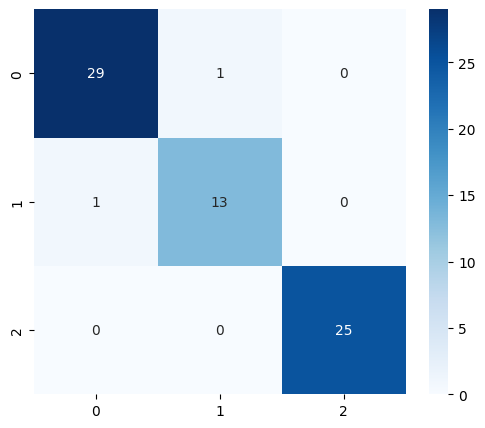

In [11]:
#Variables predictoras
X = df_modelo[["Longitud_Pico_cm",
               "Profundidad_Pico_cm",
               "Longitud_Aleta_cm",
               "Masa_Corporal_kg",
               "Sexo_Macho",
               "Isla_Dream",
               "Isla_Torgersen"]]

#Variable objetivo
y = df_modelo["Especie_num"]

#División test/train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Construcción del modelo de Red Neuronal Multicapa (MLP)
modelo_1 = MLPClassifier(

    # Arquitectura de la red:
    # Primera capa oculta con 8 neuronas y segunda capa oculta con 4 neuronas
    hidden_layer_sizes=(8,4),

    # Función de activación ReLU
    activation="relu",

    # Optimizador Adam, utilizado para ajustar los pesos de la red
    # mediante descenso de gradiente
    solver="adam",

    # Tasa de aprendizaje inicial
    learning_rate_init=0.001,

    # Número máximo de iteraciones de entrenamiento.
    max_iter=1000,

    # Semilla para garantizar resultados reproducibles
    random_state=42
)

#Entrenamiento
modelo_1.fit(X_train, y_train)

#Predicción
y_pred_1 = modelo_1.predict(X_test)
acc_1 = accuracy_score(y_test,y_pred_1)


print("\nAccuracy:")
print(acc_1)

print("\nReporte:")
print(classification_report(y_test,y_pred_1))

print("\nMatriz de confusión:")
cm_1 = confusion_matrix(y_test, y_pred_1)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_1,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True
)


La matriz de confusión muestra que, de las 69 observaciones evaluadas, 67 fueron clasificadas correctamente, lo que se refleja un accuracy del 97.1%. Para la clase 0, se identificaron correctamente 29 de 30 casos. En la clase 1, 13 de 14 observaciones fueron asignadas correctamente. Por su parte, la clase 2 presentó una clasificación perfecta, con 25 de 25 observaciones correctamente identificadas. En general, los errores se concentraron únicamente entre las clases 0 y 1, mientras que la clase 2 no presentó confusiones con las demás categorías.

## Red Neuronal 2
####Red Neuronal con estandarización, con 2 capas, correspondientes a 8 y 4 neuronas respectivamente.

Posteriormente, se construyó una segunda red neuronal utilizando la misma arquitectura de la prueba anterior, con el fin de evaluar el efecto de la estandarización sobre el desempeño del modelo. La estandarización transforma las variables de entrada a una escala comparable, evitando que aquellas con magnitudes mayores tengan una influencia desproporcionada durante el entrenamiento.



Accuracy:
1.0

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


Matriz de confusión:


<Axes: >

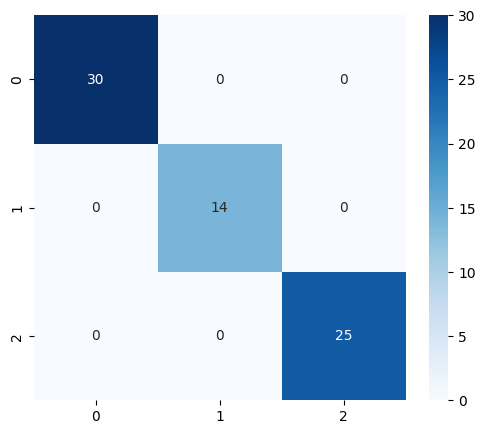

In [12]:
#Variables predictoras
X = df_modelo[["Longitud_Pico_cm",
               "Profundidad_Pico_cm",
               "Longitud_Aleta_cm",
               "Masa_Corporal_kg",
               "Sexo_Macho",
               "Isla_Dream",
               "Isla_Torgersen"]]

#Variable objetivo
y = df_modelo["Especie_num"]

#División test/train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Construcción de un Pipeline para automatizar en un solo flujo de trabajo
modelo_2 = Pipeline([

    # Estandarización de las variables de entrada
    ("scaler", StandardScaler()),

    # Construcción del modelo de Red Neuronal Multicapa (MLP)
    ("mlp", MLPClassifier(

        # Arquitectura de la red:
        # Primera capa oculta con 8 neuronas y segunda capa oculta con 4 neuronas
        hidden_layer_sizes=(8,4),

        # Función de activación ReLU
        activation="relu",

        # Optimizador Adam, utilizado para ajustar los pesos de la red
        # mediante descenso de gradiente
        solver="adam",

        # Tasa de aprendizaje inicial
        learning_rate_init=0.001,

        # Número máximo de iteraciones de entrenamiento
        max_iter=1000,

        # Semilla para garantizar resultados reproducibles
        random_state=42
    ))
])

#Entrenamiento
modelo_2.fit(X_train, y_train)

#Predicción
y_pred_2 = modelo_2.predict(X_test)
acc_2 = accuracy_score(y_test,y_pred_2)


print("\nAccuracy:")
print(acc_2)

print("\nReporte:")
print(classification_report(y_test,y_pred_2))

print("\nMatriz de confusión:")
cm_2 = confusion_matrix(y_test, y_pred_2)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_2,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True
)



La matriz de confusión muestra que, de las 69 observaciones evaluadas, las 69 fueron clasificadas correctamente, lo que se refleja en un accuracy del 100%. Para la clase 0, se identificaron correctamente 30 de 30 casos. En la clase 1, 14 de 14 observaciones fueron asignadas correctamente. Por su parte, la clase 2 presentó una clasificación perfecta, con 25 de 25 observaciones correctamente identificadas. En este caso no se registraron errores de clasificación, ya que todas las observaciones fueron asignadas a su clase correspondiente sin confusiones entre categorías.

## Red Neuronal 3
#### Red Neuronal con estandarización, con 2 capas, correspondientes a 8 y 4 neuronas respectivamente. Eliminando las variables altamente correlacionadas con la variable objetivo.

Una vez identificado el desempeño de la red utilizando estandarización, se diseñó una tercera prueba orientada al análisis de importancia de variables.
Con la finalidad de identificar las variables con mayor asociación respecto a la variable objetivo, se calculó la correlación entre las variables predictoras y la variable objetivo. El objetivo de esta prueba fue evaluar el impacto de retirar las variables más explicativas.

In [ ]:

corr_target = df_modelo.corr(numeric_only=True)

corr_target["Especie_num"].sort_values(
    ascending=False
)

,Especie_num
Especie_num,1.000000
Longitud_Aleta_cm,0.855160
Masa_Corporal_kg,0.751733
Longitud_Pico_cm,0.732410
Anio,0.035150
Sexo_Macho,0.004927
Isla_Dream,-0.311589
Isla_Torgersen,-0.434574
Profundidad_Pico_cm,-0.745276


 Los resultados mostraron que Longitud_Aleta_cm, Masa_Corporal_kg, Profundidad_Pico_cm y Longitud_Pico_cm presentaron las asociaciones más fuertes, sugiriendo una alta capacidad para distinguir entre especies.


Accuracy:
0.6956521739130435

Reporte:
              precision    recall  f1-score   support

           0       1.00      0.30      0.46        30
           1       0.54      1.00      0.70        14
           2       0.74      1.00      0.85        25

    accuracy                           0.70        69
   macro avg       0.76      0.77      0.67        69
weighted avg       0.81      0.70      0.65        69


Matriz de confusión:


<Axes: >

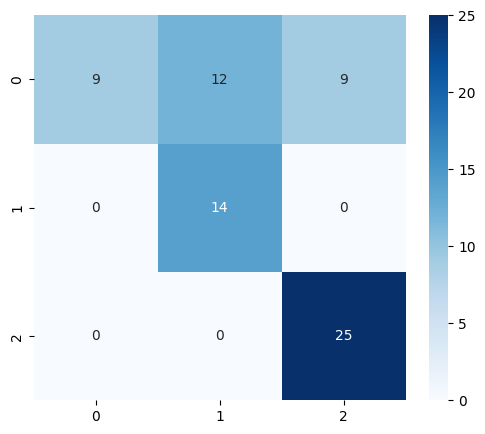

In [13]:
#Variables predictoras
X = df_modelo[["Sexo_Macho",
               "Isla_Dream",
               "Isla_Torgersen"]]

#Variable objetivo
y = df_modelo["Especie_num"]

#División test/train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Construcción de un Pipeline para automatizar en un solo flujo de trabajo
modelo_3 = Pipeline([

    # Estandarización de las variables de entrada
    ("scaler", StandardScaler()),

    # Construcción del modelo de Red Neuronal Multicapa (MLP)
    ("mlp", MLPClassifier(

        # Arquitectura de la red:
        # Primera capa oculta con 8 neuronas y segunda capa oculta con 4 neuronas
        hidden_layer_sizes=(8,4),

        # Función de activación ReLU
        activation="relu",

        # Optimizador Adam, utilizado para ajustar los pesos de la red
        # mediante descenso de gradiente
        solver="adam",

        # Tasa de aprendizaje inicial
        learning_rate_init=0.001,

        # Número máximo de iteraciones de entrenamiento
        max_iter=1000,

        # Semilla para garantizar resultados reproducibles
        random_state=42
    ))
])

#Entrenamiento
modelo_3.fit(X_train, y_train)

#Predicción
y_pred_3 = modelo_3.predict(X_test)
acc_3 = accuracy_score(y_test,y_pred_3)


print("\nAccuracy:")
print(acc_3)

print("\nReporte:")
print(classification_report(y_test,y_pred_3))

print("\nMatriz de confusión:")
cm_3 = confusion_matrix(y_test, y_pred_3)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_3,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True
)




La matriz de confusión muestra que, de las 69 observaciones evaluadas, 48 fueron clasificadas correctamente, lo que se refleja en un accuracy del 69.5%. Para la clase 0, se identificaron correctamente 9 de 30 casos, mientras que 12 fueron clasificados como clase 1 y 9 como clase 2. En la clase 1, las 14 observaciones fueron asignadas correctamente sin errores. Por su parte, la clase 2 presentó una clasificación perfecta, con 25 de 25 observaciones correctamente identificadas. En general, los errores de clasificación se concentraron principalmente en la clase 0, la cual fue confundida tanto con la clase 1 como con la clase 2, mientras que las clases 1 y 2 no presentaron confusiones entre categorías.

## Red Neuronal 4
#### Red Neuronal con estandarización, con 1 capa de 8 neuronas.

Finalmente, se construyó una cuarta red neuronal con una arquitectura más sencilla, reduciendo el número de capas ocultas a una sola capa de 8 neuronas. Esta prueba tuvo como propósito analizar si una arquitectura menos compleja era capaz de mantener niveles similares de desempeño, permitiendo evaluar el efecto de la profundidad de la red sobre la capacidad de clasificación de las especies.


Accuracy:
1.0

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


Matriz de confusión:


<Axes: >

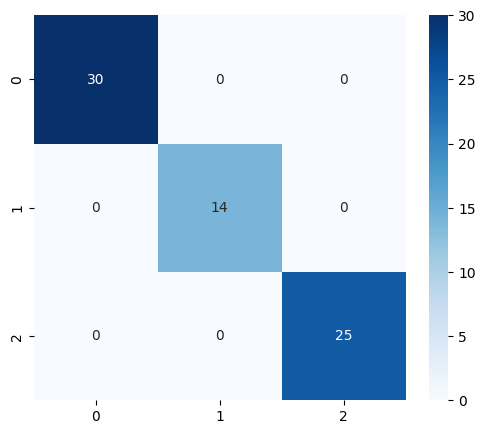

In [14]:
#Variables predictoras
X = df_modelo[["Longitud_Pico_cm",
               "Profundidad_Pico_cm",
               "Longitud_Aleta_cm",
               "Masa_Corporal_kg",
               "Sexo_Macho",
               "Isla_Dream",
               "Isla_Torgersen"]]

#Variable objetivo
y = df_modelo["Especie_num"]

#División test/train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Construcción de un Pipeline para automatizar en un solo flujo de trabajo
modelo_4 = Pipeline([

    # Estandarización de las variables de entrada
    ("scaler", StandardScaler()),

    # Construcción del modelo de Red Neuronal Multicapa (MLP)
    ("mlp", MLPClassifier(

        # Arquitectura de la red:
        # Una única capa oculta con 8 neuronas
        hidden_layer_sizes=(8,),

        # Función de activación ReLU
        activation="relu",

        # Optimizador Adam, utilizado para ajustar los pesos de la red
        # mediante descenso de gradiente
        solver="adam",

        # Tasa de aprendizaje inicial
        learning_rate_init=0.001,

        # Número máximo de iteraciones de entrenamiento
        max_iter=1000,

        # Semilla para garantizar resultados reproducibles
        random_state=42
    ))
])

#Entrenamiento
modelo_4.fit(X_train, y_train)

#Predicción
y_pred_4 = modelo_4.predict(X_test)
acc_4 = accuracy_score(y_test,y_pred_4)


print("\nAccuracy:")
print(acc_4)

print("\nReporte:")
print(classification_report(y_test,y_pred_4))

print("\nMatriz de confusión:")
cm_4 = confusion_matrix(y_test, y_pred_4)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_4,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True
)


La matriz de confusión muestra que, de las 69 observaciones evaluadas, las 69 fueron clasificadas correctamente, lo que se refleja en un accuracy del 100%. Para la clase 0, se identificaron correctamente 30 de 30 casos. En la clase 1, 14 de 14 observaciones fueron asignadas correctamente. Por su parte, la clase 2 presentó una clasificación perfecta, con 25 de 25 observaciones correctamente identificadas. En este caso no se registraron errores de clasificación, ya que todas las observaciones fueron asignadas a su clase correspondiente sin confusiones entre categorías.

In [15]:
resultados_redes = pd.DataFrame({
"Modelo": ["Red 1","Red 2","Red 3","Red 4"],
"Descripción": ["Sin estandarización (8,4)","Con estandarización (8,4)", "Sin variables mãs asociadas a la esperie (8,4)","Con estandarización (8)"],
"Accuracy": [acc_1, acc_2, acc_3, acc_4]
})
print(resultados_redes)

  Modelo                                     Descripción  Accuracy
0  Red 1                       Sin estandarización (8,4)  0.971014
1  Red 2                       Con estandarización (8,4)  1.000000
2  Red 3  Sin variables mãs asociadas a la esperie (8,4)  0.695652
3  Red 4                         Con estandarización (8)  1.000000


Los resultados obtenidos a partir de los cuatro modelos muestran variaciones importantes en el desempeño, con accuracies que van desde 0.695 hasta 1.0. Sin embargo, estos valores deben interpretarse considerando que el conjunto de datos utilizado es pequeño, con 344 registros, lo que limita la capacidad del modelo para generalizar patrones complejos y evaluar adecuadamente su comportamiento ante nuevos datos.

En este sentido, más que evidenciar una capacidad predictiva, los resultados reflejan principalmente la capacidad del modelo para capturar relaciones ya bien definidas dentro de los datos, lo cual es consistente con lo observado en el análisis exploratorio previo. Las gráficas mostraron que las especies presentan una separación bastante marcada en función de variables como la masa corporal, la longitud de la aleta y las características del pico, lo que facilita la clasificación y sugiere que existen patrones estructurales claros en los datos.

En conjunto, el comportamiento de los modelos está fuertemente condicionado por la estructura de los datos y las relaciones visibles entre las variables, por lo que los resultados deben interpretarse más como una descripción de patrones existentes que como una evidencia de capacidad predictiva generalizable.

